<center><h1>Преобразование признаков перед машинным обучением.</h1></center>

In [2]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np

from feature_engineering import (
                                train_test,
                                OutsideInsideMetro,
                                picture_cluster,
                                picture_hue_clusters,         
                                DistrictKMeansEncoder,
                                CoffForMetroMinutes,
                                MetroTargetEncoder,
                                SellerTypeDrop,
                                DropColumns)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import shap
from sklearn.pipeline import Pipeline
from catboost import CatBoostRegressor

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
data = pd.read_csv('/Users/muzaladinovdzamalladinruslanovic/Desktop/PROJECT CIAN/data/full data/cian_preprocessing.csv', index_col=0)
data.head()

,rooms,area,floor,floors_total,metro,metro_minutes,metro_transport,district,seller_type,price_rub
0,4.0,86.0,3,18,Корниловская,18.0,walk,Мосрентген,agency,26285040.0
1,1.0,33.4,2,9,Кокошкино,6.0,walk,Кокошкино,specialist,11000000.0
2,1.0,33.1,1,5,Щёлковская,7.0,walk,Северное Измайлово,specialist,12500000.0
3,1.0,41.3,25,27,Тушинская,8.0,transport,Покровское-Стрешнево,specialist,17500000.0
4,0.0,31.6,32,47,Печатники,13.0,walk,Печатники,agency,19842057.0


<h2>1. Деление выборки на train и test</h2>

In [15]:
X_train, X_test, y_train, y_test = train_test(data)
print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

Train: 18102 | Test: 7758


* выборка поделена на обучающую и тестовую.

<h2>2. Выбор количества кластеров для районов</h2>

Признак district содержит 150+ уникальных значений — это слишком много для модели
и увеличивает риск переобучения. 

Идея: заменить название района на номер кластера (5 групп), 
используя следующие признаки:
- price_med, price_mean — ценовой уровень района
- avg_minutes — среднее время до метро
- walk_share — доля квартир у метро пешком
- in_moscow — находится ли район внутри МКАД

*Примечание: признак in_moscow будет создан в пайплайне, 
но для оценки качества кластеризации добавлен заранее.*

Оптимальное количество кластеров подбирается через Elbow Method и коэффициент силуэта.

n_clusters=2: silhouette=0.4215
n_clusters=3: silhouette=0.4823
n_clusters=4: silhouette=0.4583
n_clusters=5: silhouette=0.5131
n_clusters=6: silhouette=0.4828
n_clusters=7: silhouette=0.4740
n_clusters=8: silhouette=0.3279
n_clusters=9: silhouette=0.3260
n_clusters=10: silhouette=0.3476
n_clusters=11: silhouette=0.3448


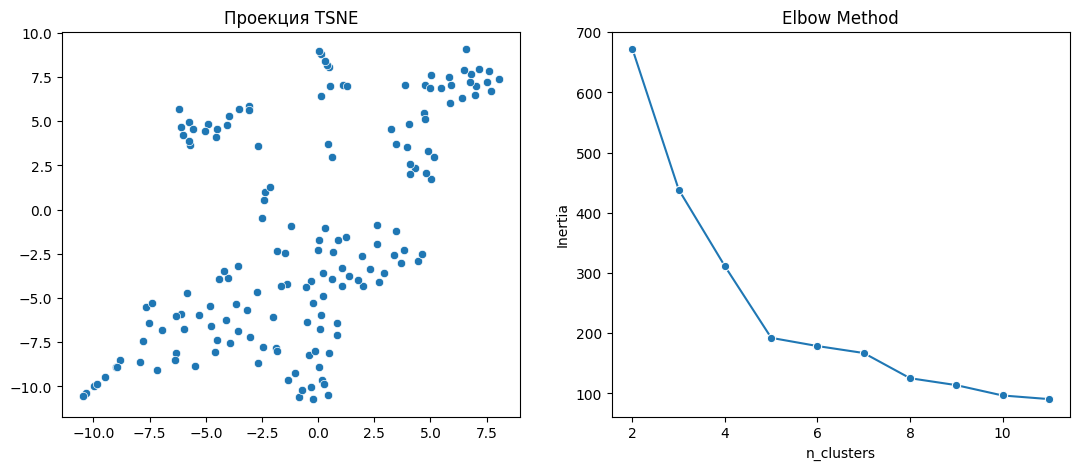

In [16]:
picture_cluster(pd.concat([X_train, y_train], axis=1))

Для определения оптимального числа кластеров были использованы два метода:

- **Elbow Method** — показал перелом в районе 5 кластеров
- **Коэффициент силуэта** — максимальное значение 0.5051 достигается при n=5

Оба метода сошлись на **5 кластерах** — это оптимальное разделение районов Москвы, 
которое интерпретируется как:

Признак district_cluster будет добавлен в пайплайн через DistrictKMeansEncoder
вместо сырого district (150+ уникальных значений) — это снижает риск переобучения 
и улучшает обобщающую способность модели.

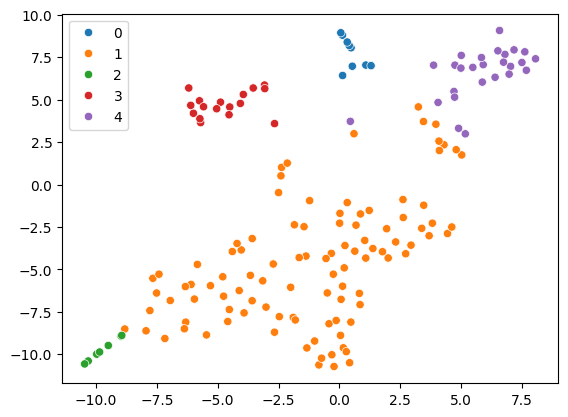

In [17]:
picture_hue_clusters(pd.concat([X_train, y_train], axis=1))

* приведу изображение, на котором видно, что кластеры разделились хорошо. Метод кластеризации KMeans явно выделил 5 районов.

## Feature Engineering

### Подготовка выборки
Данные разделены на **Train** и **Test** с параметрами `test_size=0.3`, `random_state=42`.
Стратификация по признаку `in_moscow` — для сохранения пропорции объектов за МКАД (12%) в обеих выборках.

---

### Созданные трансформеры

#### 1. `OutsideInsideMetro`
Создаёт бинарный признак `in_moscow` — находится ли станция метро внутри МКАД:
- `1` — станция внутри МКАД
- `0` — станция за пределами МКАД

В ходе EDA было установлено, что квартиры за МКАД стоят кратно дешевле — признак является значимым для ценообразования.

---

#### 2. `CoffForMetroMinutes`
Корректирует признак `metro_minutes` с учётом типа транспорта до метро.

Если `metro_transport = 'transport'` — время умножается на коэффициент **2.5**.  
Коэффициент выбран на основе исследований транспортной доступности в Москве:
поездка на транспорте субъективно воспринимается в 2.5 раза длиннее пешей прогулки.

После преобразования признак `metro_transport` удаляется.

---

#### 3. `DistrictKMeansEncoder`
Заменяет признак `district` (150+ уникальных значений) на номер кластера (0–4).

**Почему не сырой `district`:**
- Большое количество уникальных значений увеличивает риск переобучения
- Редкие районы имеют мало объявлений — статистики ненадёжны

**Как определялось оптимальное число кластеров:**
- TSNE — визуализация структуры районов на плоскости
- Метод локтя — перелом на значении **n=5**
- Коэффициент силуэта — максимум **0.505** при n=5

**Признаки для кластеризации** (считаются только на Train):

| Признак | Описание |
|---|---|
| `price_mean`, `price_med` | Средняя и медианная цена в районе |
| `avg_minutes` | Среднее время до метро |
| `walk_share` | Доля квартир у метро пешком |
| `in_moscow` | Доля станций внутри МКАД |

---

#### 4. `MetroTargetEncoder`
Заменяет название станции метро (`metro`) на среднюю цену квартир у данной станции.

**Почему не сырой `metro`:**
- 200+ уникальных значений — высокий риск переобучения
- OrdinalEncoder не несёт смысла — порядковой зависимости между станциями нет

**Важно:** средняя цена считается **только на Train** — утечки нет.  
Для станций которые встречаются только в Test используется глобальная средняя цена по всей выборке.

---

#### 5. `SellerTypeDrop`
Удаляет признак `seller_type`.

В ходе EDA было установлено что медианные цены по типам продавцов практически не различаются
(агентства — 578к ₽/м², специалисты — 480к ₽/м², собственники — 500к ₽/м²).
Признак не несёт значимого сигнала и является шумом.

---

### Итоговый пайплайн

```python
Pipeline([
    ('mkad',     OutsideInsideMetro()),       # создаёт in_moscow
    ('district', DistrictKMeansEncoder()),    # кластеризует районы, использует metro_transport
    ('minutes',  CoffForMetroMinutes()),      # корректирует минуты, удаляет metro_transport
    ('metro',    MetroTargetEncoder()),       # target encoding для станций метро
    ('seller',   SellerTypeDrop()),           # удаляет seller_type
    ('model',    CatBoostRegressor()),
])
```

### Результирующие признаки

| Признак | Тип | Описание |
|---|---|---|
| `rooms` | int | Количество комнат |
| `area` | float | Площадь квартиры |
| `floor` | int | Этаж |
| `floors_total` | int | Этажей в доме |
| `metro_minutes` | float | Скорректированное время до метро |
| `in_moscow` | int | Внутри МКАД (1) или нет (0) |
| `district_cluster` | int | Кластер района (0–4) |
| `metro_encoded` | float | Средняя цена по станции метро |

--------------------TRAIN--------------------
MAE:        5,833,865 ₽
RMSE:      10,041,049 ₽
R²:            0.9921
--------------------TEST---------------------
MAE:       12,692,936 ₽
RMSE:      34,802,736 ₽
R²:            0.8901


/Users/muzaladinovdzamalladinruslanovic/Desktop/work/venv/lib/python3.13/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


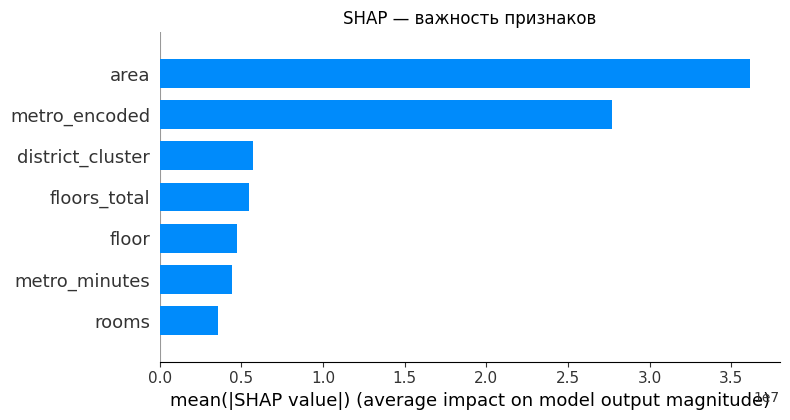

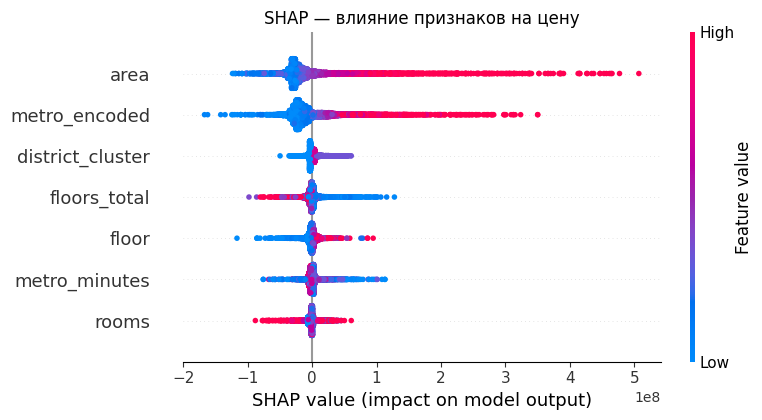

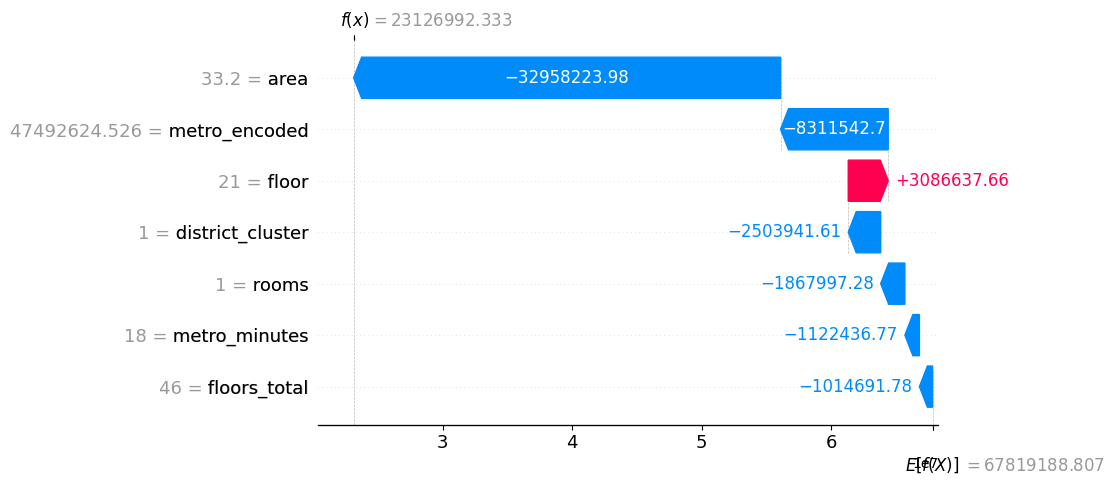

In [ ]:
best_params = {
    'iterations':          927,
    'learning_rate':       0.1859908390113456,
    'depth':               8,
    'l2_leaf_reg':         2.627401592508217,
    'bagging_temperature': 0.5155525450602909,
    'random_state':        42,
    'verbose':             0
}

# Финальная модель
pipe_final = Pipeline([
    ('mkad',     OutsideInsideMetro()),
    ('district', DistrictKMeansEncoder()),
    ('minutes',  CoffForMetroMinutes()),
    ('metro',    MetroTargetEncoder()),
    ('seller',   SellerTypeDrop()),
    ('drop',     DropColumns(columns=['in_moscow'])),
    ('cb',       CatBoostRegressor(**best_params))
])

pipe_final.fit(X_train, y_train)

pred_train = pipe_final.predict(X_train)
pred_test  = pipe_final.predict(X_test)

print("=" * 45)
print(f"{'TRAIN':-^45}")
print(f"MAE:  {mean_absolute_error(y_train, pred_train):>15,.0f} ₽")
print(f"RMSE: {mean_squared_error(y_train, pred_train) ** 0.5:>15,.0f} ₽")
print(f"R²:   {r2_score(y_train, pred_train):>15.4f}")
print("=" * 45)
print(f"{'TEST':-^45}")
print(f"MAE:  {mean_absolute_error(y_test, pred_test):>15,.0f} ₽")
print(f"RMSE: {mean_squared_error(y_test, pred_test) ** 0.5:>15,.0f} ₽")
print(f"R²:   {r2_score(y_test, pred_test):>15.4f}")
print("=" * 45)

# SHAP
X_test_transformed = pipe_final[:-1].transform(X_test)
explainer = shap.TreeExplainer(pipe_final['cb'])
shap_values = explainer.shap_values(X_test_transformed)

# График 1 — важность признаков
shap.summary_plot(shap_values, X_test_transformed, plot_type='bar', show=False)
plt.title('SHAP — важность признаков')
plt.tight_layout()
plt.show()

# График 2 — направление влияния
shap.summary_plot(shap_values, X_test_transformed, show=False)
plt.title('SHAP — влияние признаков на цену')
plt.tight_layout()
plt.show()

# График 3 — объяснение одного предсказания
shap_explanation = explainer(X_test_transformed)
shap.waterfall_plot(shap_explanation[0])

`ВЫВОД В README.md`